In [ ]:
import numpy as np
import random
from collections import deque, defaultdict
import heapq

# ─── 地圖與參數 ─────────────────────────────────────────
WIDTH, HEIGHT = 21, 11
treasure_list = [(0,6),(3,16),(8,2),(10,2),(10,17)]
walls_coords  = { ... }   # 省略你的牆座標
START, GOAL = (0,0), (20,10)

# Q-learning 超參數
MAX_EPISODES = 1000
MAX_STEPS    = 1000
EPSILON, EPS_DECAY, EPS_MIN = 0.9, 0.999, 0.05
ALPHA, GAMMA = 0.9, 0.995

# Prioritized Sweeping 參數
PLANNING_STEPS     = 50
PRIORITY_THRESHOLD = 1e-4

ACTIONS     = ['up','down','left','right']
NUM_ACTIONS = len(ACTIONS)
NUM_MASK    = 1 << len(treasure_list)
NUM_STATES  = WIDTH*HEIGHT * NUM_MASK

Q1 = np.zeros((NUM_STATES,NUM_ACTIONS))
Q2 = np.zeros((NUM_STATES,NUM_ACTIONS))

Model          = {}
predecessors   = defaultdict(list)
priority_queue = []

# 禁止回頭用
opposite = {'up':'down','down':'up','left':'right','right':'left'}

def to_index(pos):     return pos[1]*WIDTH + pos[0]
def encode_state(pos,mask): return to_index(pos)*NUM_MASK + mask
def compute_target(pos,act):
    x,y=pos
    if act=='up':    y=max(0,y-1)
    elif act=='down':y=min(HEIGHT-1,y+1)
    elif act=='left':x=max(0,x-1)
    else:            x=min(WIDTH-1,x+1)
    return (x,y)

best_steps, best_score, best_path = MAX_STEPS+1, -1, None
best_treasure_score, best_treasure_path = -1, None
epsilon = EPSILON

for ep in range(1, MAX_EPISODES+1):
    pos, mask = START, 0
    s = encode_state(pos,mask)
    path  = [s]
    score = 0
    prev_a = None       # ← 上一步做的動作索引
    recent_states = deque(maxlen=10)
    visit_count   = defaultdict(int)
    visit_count[s]=1

    for step in range(1, MAX_STEPS+1):
        # ─── 1) 選動作：ε-貪婪 + 禁止回頭 + 避免短期重訪 + 障礙檢查 ─────────────────
        while True:
            if random.random()<epsilon:
                a = random.randrange(NUM_ACTIONS)
            else:
                a = np.argmax(Q1[s]+Q2[s])
            # 禁止立即走回頭路（同一包內狀態）
            if prev_a is not None and ACTIONS[a]==opposite[ACTIONS[prev_a]]:
                continue
            new_pos = compute_target(pos, ACTIONS[a])
            s2 = encode_state(new_pos, mask)
            if new_pos in walls_coords or new_pos==pos or s2 in recent_states:
                continue
            break

        # ─── 2) 計算獎勵 & 更新 mask; 撿到寶藏時重置 prev_a ─────────────────────────
        r = -1
        new_mask = mask
        picked = False
        if new_pos in treasure_list:
            i = treasure_list.index(new_pos)
            if not (mask & (1<<i)):
                new_mask |= (1<<i)
                r = +10
                score += 1
                picked = True
        elif new_pos==GOAL:
            r = +58 if new_mask==(NUM_MASK-1) else -50

        # 拾金返身：撿到寶藏後清除禁止回頭的記錄
        if picked:
            prev_a = None

        s2 = encode_state(new_pos,new_mask)

        # ─── 3) Double Q-Learning 本步更新 ─────────────────────────────────────────
        if random.random()<0.5:
            a2 = np.argmax(Q1[s2])
            td = r + GAMMA*Q2[s2,a2] - Q1[s,a]
            Q1[s,a] += ALPHA*td
        else:
            a2 = np.argmax(Q2[s2])
            td = r + GAMMA*Q1[s2,a2] - Q2[s,a]
            Q2[s,a] += ALPHA*td

        # ─── 4) Model & predecessors ─────────────────────────────────────────────
        Model[(s,a)] = (r,s2)
        predecessors[s2].append((s,a))

        # ─── 5) push priority ────────────────────────────────────────────────────
        if abs(td)>PRIORITY_THRESHOLD:
            heapq.heappush(priority_queue,(-abs(td),s,a))

        # ─── 6) Prioritized Sweeping 規劃更新 ────────────────────────────────────
        for _ in range(PLANNING_STEPS):
            if not priority_queue: break
            _,sp,ap = heapq.heappop(priority_queue)
            rp,sp2 = Model[(sp,ap)]
            if random.random()<0.5:
                anp = np.argmax(Q1[sp2])
                td2 = rp + GAMMA*Q2[sp2,anp] - Q1[sp,ap]
                Q1[sp,ap] += ALPHA*td2
            else:
                anp = np.argmax(Q2[sp2])
                td2 = rp + GAMMA*Q1[sp2,anp] - Q2[sp,ap]
                Q2[sp,ap] += ALPHA*td2

            for spre,apre in predecessors[sp]:
                rpre,spre2 = Model[(spre,apre)]
                qtar = rpre + GAMMA*max(Q1[spre2],Q2[spre2])
                qpred= max(Q1[spre,apre],Q2[spre,apre])
                if abs(qtar-qpred)>PRIORITY_THRESHOLD:
                    heapq.heappush(priority_queue,(-abs(qtar-qpred),spre,apre))

        # ─── 7) 真實移動與更新輔助狀態 ───────────────────────────────────────────
        pos, mask, s = new_pos, new_mask, s2
        path.append(s2)
        recent_states.append(s2)
        prev_a = a

        # 成功判斷
        if pos==GOAL and mask==(NUM_MASK-1):
            if step<best_steps:
                best_steps,best_score,best_path = step,score,path.copy()
            break

    # 更新「最多寶藏」軌跡
    if score>best_treasure_score:
        best_treasure_score,best_treasure_path = score,path.copy()

    # ε 衰減 & 印進度
    epsilon = max(EPS_MIN, epsilon*EPS_DECAY)
    if ep%50==0 or ep in (1,MAX_EPISODES):
        print(f"Ep{ep:4d} | ε={epsilon:.3f} | best_steps={best_steps} | best_score={best_score}")

# ─── 輸出最終結果 ───────────────────────────────────────────
if best_path is not None:
    use_path,label,final_score = best_path,"（成功）",best_score
else:
    use_path,label,final_score = best_treasure_path,"（未成功，以寶藏數最多輸出）",best_treasure_score

# 重播 & 輸出
collected=[]
pos,mask=START,0
for state in use_path:
    idx=state//NUM_MASK; x=idx%WIDTH; y=idx//WIDTH
    if (x,y) in treasure_list and (x,y) not in collected:
        collected.append((x,y))
    pos=(x,y)

print(f"=== 最終結果 {label} ===")
print(f"步數：{len(use_path)-1}")
print(f"寶藏：{final_score}/{len(treasure_list)} -> {collected}")
print(f"最終停留：{pos} (應為 {GOAL})")

Ep   1 | ε=0.895 | best_steps=1001 | best_score=-1
Ep  50 | ε=0.700 | best_steps=1001 | best_score=-1
Ep 100 | ε=0.545 | best_steps=1001 | best_score=-1
Ep 150 | ε=0.424 | best_steps=1001 | best_score=-1
Ep 200 | ε=0.330 | best_steps=1001 | best_score=-1
Ep 250 | ε=0.257 | best_steps=1001 | best_score=-1
Ep 300 | ε=0.200 | best_steps=1001 | best_score=-1
Ep 350 | ε=0.156 | best_steps=1001 | best_score=-1
Ep 400 | ε=0.121 | best_steps=1001 | best_score=-1
Ep 450 | ε=0.094 | best_steps=1001 | best_score=-1
Ep 500 | ε=0.073 | best_steps=1001 | best_score=-1
Ep 550 | ε=0.057 | best_steps=1001 | best_score=-1
Ep 600 | ε=0.044 | best_steps=1001 | best_score=-1
Ep 650 | ε=0.035 | best_steps=1001 | best_score=-1
Ep 700 | ε=0.027 | best_steps=1001 | best_score=-1
Ep 750 | ε=0.021 | best_steps=1001 | best_score=-1
Ep 800 | ε=0.016 | best_steps=1001 | best_score=-1
Ep 850 | ε=0.013 | best_steps=1001 | best_score=-1
Ep 900 | ε=0.010 | best_steps=1001 | best_score=-1
Ep 950 | ε=0.010 | best_steps=1

In [ ]:
# 假设 use_path 是最佳轨迹的 state 序列
coords = []
for s in use_path:
    idx = s // NUM_MASK
    x, y = idx % WIDTH, idx // WIDTH
    coords.append((x,y))

# 打印前 100 步坐标
#print("前100步坐标：", coords[:100])

# 或者整条路径
print("完整轨迹：", coords)

前100步坐标： [(0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (0, 3), (1, 3), (0, 3), (0, 2), (0, 1), (0, 2), (0, 1), (0, 2), (0, 3), (0, 2), (0, 3), (1, 3), (0, 3), (0, 2), (0, 1), (0, 2), (0, 3), (1, 3), (0, 3), (0, 2), (0, 1), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 1), (0, 2), (0, 1), (0, 2), (0, 1), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 1), (0, 0), (0, 1), (0, 2), (0, 1), (0, 2), (0, 1), (0, 2), (0, 3), (0, 2), (0, 1), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (0, 1), (0, 0), (1, 0), (0, 0), (0, 1), (0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (0, 3), (1, 3), (0, 3), (1, 3), (0, 3), (0, 2), (0, 3), (0, 2), (0, 1), (0, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (0, 0), (1, 0)]
完整轨迹： [(0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (0, 3), (1, 3), (0, 3), (0, 2), (0, 1), (0, 2), (0, 1), (0, 2), (0, 3), (0, 2), (0, 3), (1, 3),

c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23453 (\N{CJK UNIFIED IDEOGRAPH-5B9D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 34255 (\N{CJK UNIFIED IDEOGRAPH-85CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) miss

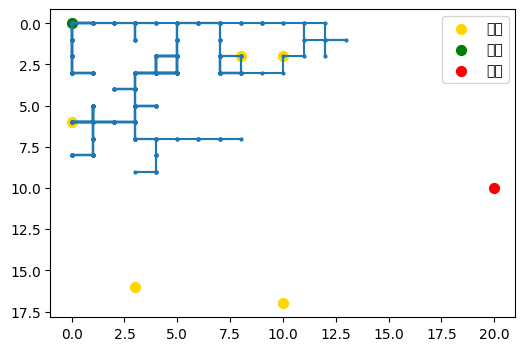

In [5]:
import matplotlib.pyplot as plt

xs, ys = zip(*coords)
plt.figure(figsize=(6,4))
plt.plot(xs, ys, '-o', markersize=2)
# 标注宝藏、起点、终点
tx, ty = zip(*treasure_list)
plt.scatter(tx, ty, c='gold', label='宝藏', s=50)
plt.scatter(START[0], START[1], c='green', label='起点',  s=50)
plt.scatter(GOAL[0],  GOAL[1],  c='red',   label='终点', s=50)
plt.gca().invert_yaxis()  # (0,0) 在左上角
plt.legend()
plt.show()